# Valoraciones, usuarios estimados y tiempo de juego

## Pregunta principal

Existe relacion entre las valoraciones positivas, el numero de usuarios estimados y el tiempo medio de juego?

En este notebook analizamos si los juegos mejor valorados tambien tienden a tener mas usuarios estimados o mas tiempo medio de juego.

## 1. Importar librerias

Usamos `pandas` para trabajar con tablas y `matplotlib` para crear graficos.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("default")

# Formateador para numeros grandes: 100.000, 1.000.000, etc.
def formato_miles(valor, posicion):
    return f"{valor:,.0f}".replace(",", ".")

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Cargar los datos

Cargamos la tabla limpia de juegos generada por el script `src/analyze_genres.py`.

In [2]:
# Detectamos automaticamente la carpeta del proyecto.
cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd / "Steam_Games_2025"]

PROJECT_ROOT = next(
    path for path in candidates
    if (path / "data" / "processed" / "juegos_steam_limpio_base.csv").exists()
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
print("Carpeta del proyecto:", PROJECT_ROOT)

juegos = pd.read_csv(DATA_PROCESSED / "juegos_steam_limpio_base.csv")
juegos.head()

Carpeta del proyecto: C:\Users\djsmd\Desktop\DANI\Master Evolve\DATA_SCIENCE_ABRIL\Proyectos\Steam_Games_2025


,id_app,nombre,ano_lanzamiento,lista_generos,usuarios_estimados_rango,usuarios_estimados_aprox,tiempo_medio_minutos,tiempo_medio_horas,resenas_positivas,resenas_negativas,total_resenas,proporcion_positivas,precio,es_gratis
0,730,Counter-Strike 2,2012,"['Accion', 'Gratis']",100000000 - 200000000,150000000.0,33189,553.150000,7480813,1135108,8615921,0.868255,0.00,True
1,578080,PUBG: BATTLEGROUNDS,2017,"['Accion', 'Aventura', 'Multijugador masivo', ...",50000000 - 100000000,75000000.0,0,0.000000,1487960,1024436,2512396,0.592247,0.00,True
2,570,Dota 2,2013,"['Accion', 'Estrategia', 'Gratis']",200000000 - 500000000,350000000.0,43031,717.183333,1998462,451338,2449800,0.815765,0.00,True
3,271590,Grand Theft Auto V Legacy,2015,"['Accion', 'Aventura']",50000000 - 100000000,75000000.0,19323,322.050000,1719950,250012,1969962,0.873088,0.00,True
4,488824,Tom Clancy's Rainbow Six® Siege,2015,['Accion'],0 - 20000,10000.0,0,0.000000,312816,64201,377017,0.829713,19.99,False


### Variables importantes

- `usuarios_estimados_aprox`: punto medio del rango de usuarios estimados.
- `tiempo_medio_horas`: tiempo medio acumulado convertido a horas.
- `proporcion_positivas`: proporcion de resenas positivas.
- `total_resenas`: total de resenas positivas y negativas.

Estas variables no miden exactamente lo mismo: usuarios estimados mide alcance, tiempo medio mide uso o retencion, y proporcion de positivas mide satisfaccion.

## 3. Preparar datos para el analisis

No todos los juegos sirven igual para este analisis. Si un juego tiene muy pocas resenas, su proporcion positiva puede ser poco fiable. Por ejemplo, un juego con 1 resena positiva tendria 100% de valoracion positiva, pero no seria representativo.

Por eso creamos una tabla filtrada con juegos que tengan al menos 50 resenas.

In [3]:
# Filtramos juegos con suficientes resenas para que la proporcion positiva sea mas fiable.
juegos_con_resenas = juegos[juegos["total_resenas"] >= 50].copy()

# Para el tiempo, creamos una version solo con juegos cuyo tiempo es mayor que 0.
juegos_con_tiempo = juegos_con_resenas[juegos_con_resenas["tiempo_medio_horas"] > 0].copy()

print("Juegos totales:", len(juegos))
print("Juegos con al menos 50 resenas:", len(juegos_con_resenas))
print("Juegos con al menos 50 resenas y tiempo registrado:", len(juegos_con_tiempo))

Juegos totales: 94948
Juegos con al menos 50 resenas: 27141
Juegos con al menos 50 resenas y tiempo registrado: 7454


### Interpretacion del filtro

Este filtro reduce el dataset, pero hace que el analisis sea mas serio. Preferimos analizar menos juegos con valoraciones algo mas fiables que incluir juegos con 1 o 2 resenas que pueden distorsionar mucho los resultados.

## 4. Estadisticas generales

Antes de mirar relaciones, revisamos las estadisticas principales de usuarios estimados, tiempo medio, proporcion positiva y total de resenas.

In [4]:
columnas_analisis = [
    "usuarios_estimados_aprox",
    "tiempo_medio_horas",
    "proporcion_positivas",
    "total_resenas",
]

juegos_con_resenas[columnas_analisis].describe().round(2)

,usuarios_estimados_aprox,tiempo_medio_horas,proporcion_positivas,total_resenas
count,2.714100e+04,27141.00,27141.00,27141.00
mean,3.048010e+05,6.27,0.78,4944.80
std,3.037965e+06,206.32,0.16,67254.52
min,1.000000e+04,0.00,0.00,50.00
25%,1.000000e+04,0.00,0.69,98.00
50%,3.500000e+04,0.00,0.82,238.00
75%,1.500000e+05,0.23,0.90,891.00
max,3.500000e+08,24383.28,1.00,8615921.00


### Como leer esta tabla

- `mean`: media.
- `50%`: mediana, es decir, el valor central.
- `max`: valor maximo.

En datasets de videojuegos suele haber mucha diferencia entre media y mediana, porque hay pocos juegos enormes y muchisimos juegos pequenos. Por eso no conviene quedarse solo con la media.

## 5. Correlaciones

La correlacion mide si dos variables tienden a moverse juntas.

- Cerca de 1: relacion positiva fuerte.
- Cerca de -1: relacion negativa fuerte.
- Cerca de 0: relacion lineal debil o inexistente.

Importante: correlacion no significa causalidad. Si dos variables se relacionan, no implica automaticamente que una cause la otra.

In [5]:
# Calculamos correlaciones sobre juegos con al menos 50 resenas.
correlaciones = juegos_con_resenas[columnas_analisis].corr().round(3)
correlaciones

,usuarios_estimados_aprox,tiempo_medio_horas,proporcion_positivas,total_resenas
usuarios_estimados_aprox,1.000,0.033,0.029,0.700
tiempo_medio_horas,0.033,1.000,0.005,0.031
proporcion_positivas,0.029,0.005,1.000,0.036
total_resenas,0.700,0.031,0.036,1.000


### Interpretacion

Esta tabla nos ayuda a detectar relaciones generales. Si la correlacion entre `proporcion_positivas` y `usuarios_estimados_aprox` es baja, significaria que tener mejores valoraciones no implica necesariamente tener mas usuarios estimados.

Tambien podemos mirar si `tiempo_medio_horas` se relaciona con `proporcion_positivas`, para ver si los juegos mejor valorados tienden a retener mas tiempo a los jugadores.

## 6. Usuarios estimados segun valoracion del juego

Para que el grafico sea facil de entender, dividimos los juegos en tres grupos segun su porcentaje de valoraciones positivas:

- Baja: menos de 60%.
- Media: entre 60% y 80%.
- Alta: mas de 80%.

Despues calculamos cuantos usuarios estimados tiene de media un juego de cada grupo.


In [6]:
# Creamos grupos sencillos de valoracion positiva.
juegos_con_resenas["grupo_valoracion"] = pd.cut(
    juegos_con_resenas["proporcion_positivas"] * 100,
    bins=[-1, 60, 80, 100],
    labels=["Baja (<60%)", "Media (60-80%)", "Alta (>80%)"],
)

# Calculamos usuarios estimados medios para cada grupo de valoracion.
resumen_valoracion = (
    juegos_con_resenas.groupby("grupo_valoracion", observed=False)
    .agg(
        usuarios_estimados_media=("usuarios_estimados_aprox", "mean"),
        cantidad_juegos=("id_app", "count"),
    )
    .reset_index()
)

resumen_valoracion["usuarios_estimados_media"] = resumen_valoracion["usuarios_estimados_media"].round(0).astype("int64")
resumen_valoracion


,grupo_valoracion,usuarios_estimados_media,cantidad_juegos
0,Baja (<60%),171680,3706
1,Media (60-80%),227334,8881
2,Alta (>80%),385970,14554


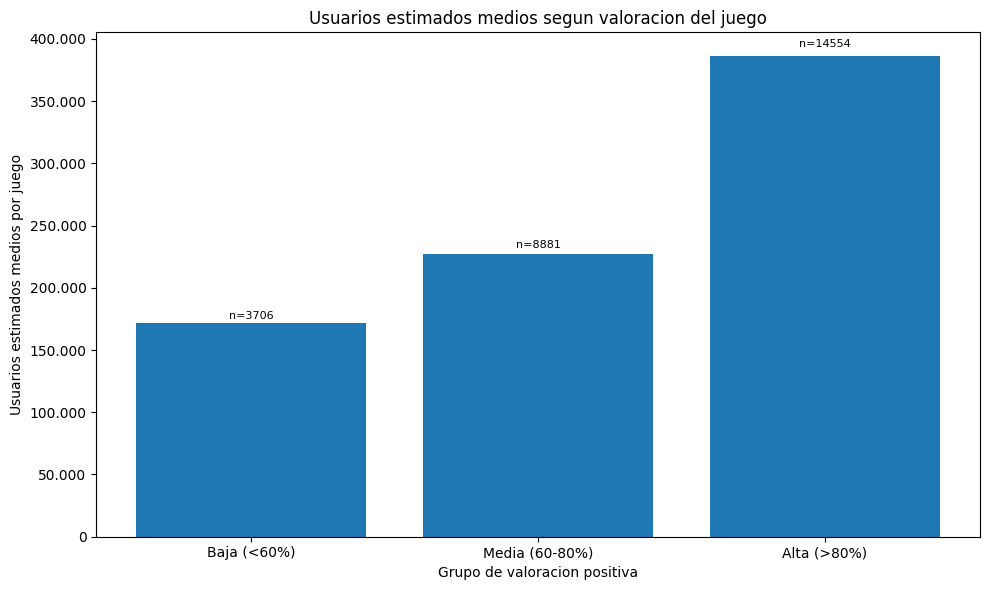

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    resumen_valoracion["grupo_valoracion"].astype(str),
    resumen_valoracion["usuarios_estimados_media"],
)

ax.set_title("Usuarios estimados medios segun valoracion del juego")
ax.set_xlabel("Grupo de valoracion positiva")
ax.set_ylabel("Usuarios estimados medios por juego")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

# Anadimos cuantos juegos hay en cada grupo.
for index, row in resumen_valoracion.iterrows():
    ax.text(
        index,
        row["usuarios_estimados_media"] * 1.02,
        f"n={int(row['cantidad_juegos'])}",
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


### Interpretacion

Este grafico se lee de forma directa: compara cuantos usuarios estimados tiene de media un juego con valoracion baja, media o alta.

Si la barra de valoracion alta fuera claramente mayor, podriamos decir que los juegos mejor valorados tienden a tener mas usuarios. Si las barras son parecidas, la relacion no parece fuerte.

El texto sobre cada barra indica cuantos juegos hay en cada grupo.


## 7. Tiempo medio de juego segun valoracion

Ahora usamos los mismos tres grupos de valoracion, pero comparamos el tiempo medio de juego.

Aqui usamos solo juegos con tiempo registrado mayor que 0, para evitar que los valores 0 oculten el patron real.


In [8]:
# Nos quedamos con juegos que tienen tiempo registrado.
juegos_con_tiempo = juegos_con_resenas[juegos_con_resenas["tiempo_medio_horas"] > 0].copy()

# Calculamos el tiempo medio para cada grupo de valoracion.
resumen_tiempo_valoracion = (
    juegos_con_tiempo.groupby("grupo_valoracion", observed=False)
    .agg(
        tiempo_medio_horas=("tiempo_medio_horas", "mean"),
        cantidad_juegos=("id_app", "count"),
    )
    .reset_index()
)

resumen_tiempo_valoracion["tiempo_medio_horas"] = resumen_tiempo_valoracion["tiempo_medio_horas"].round(2)
resumen_tiempo_valoracion


,grupo_valoracion,tiempo_medio_horas,cantidad_juegos
0,Baja (<60%),17.81,881
1,Media (60-80%),18.89,2448
2,Alta (>80%),26.26,4125


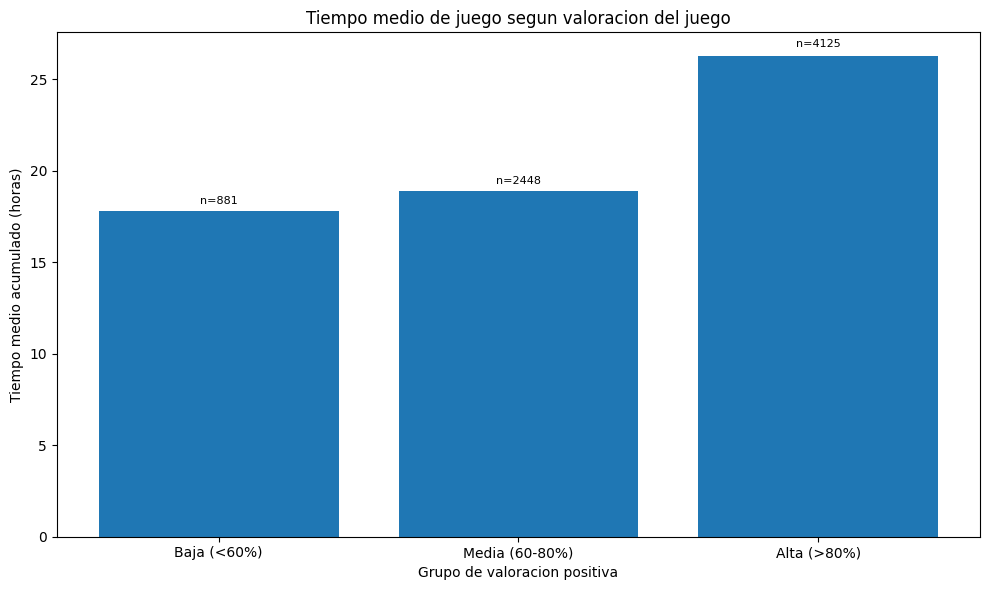

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    resumen_tiempo_valoracion["grupo_valoracion"].astype(str),
    resumen_tiempo_valoracion["tiempo_medio_horas"],
)

ax.set_title("Tiempo medio de juego segun valoracion del juego")
ax.set_xlabel("Grupo de valoracion positiva")
ax.set_ylabel("Tiempo medio acumulado (horas)")

for index, row in resumen_tiempo_valoracion.iterrows():
    ax.text(
        index,
        row["tiempo_medio_horas"] * 1.02,
        f"n={int(row['cantidad_juegos'])}",
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


### Interpretacion

Este grafico compara si los juegos mejor valorados tienen mas tiempo medio de juego.

Si la barra de valoracion alta es mayor, podria indicar que los juegos mejor valorados retienen mas a los jugadores. Si no hay una subida clara, entonces valoracion y tiempo medio no parecen estar muy relacionados.


## 8. Juegos destacados: muchos usuarios y buenas valoraciones

Buscamos juegos que combinan muchas resenas, muchos usuarios estimados y una proporcion alta de valoraciones positivas.

In [10]:
# Filtramos juegos con bastante evidencia: al menos 10.000 resenas.
juegos_destacados = juegos[juegos["total_resenas"] >= 10_000].copy()

# Ordenamos por proporcion positiva y luego por usuarios estimados.
juegos_destacados = juegos_destacados.sort_values(
    ["proporcion_positivas", "usuarios_estimados_aprox"],
    ascending=[False, False],
)

juegos_destacados[
    [
        "nombre",
        "usuarios_estimados_aprox",
        "total_resenas",
        "proporcion_positivas",
        "tiempo_medio_horas",
        "precio",
        "es_gratis",
    ]
].head(15)

,nombre,usuarios_estimados_aprox,total_resenas,proporcion_positivas,tiempo_medio_horas,precio,es_gratis
1750,Papa's Freezeria Deluxe,150000.0,10760,0.992751,0.000000,5.99,False
1321,A Short Hike,350000.0,18359,0.991775,4.383333,7.99,False
59956,Aseprite,1500000.0,20721,0.991313,0.000000,19.99,False
912,Senren＊Banka,750000.0,30009,0.989003,9.850000,19.94,False
1541,Our Life: Beginnings & Always,350000.0,12107,0.988271,4.733333,0.00,True
1426,Grimm's Hollow,750000.0,13715,0.986147,0.000000,0.00,True
1137,ATRI -My Dear Moments-,350000.0,20318,0.986022,8.416667,10.49,False
61,People Playground,7500000.0,275030,0.985914,51.133333,9.99,False
1327,The Room 4: Old Sins,350000.0,15881,0.985580,4.850000,8.99,False
71,Vampire Survivors,7500000.0,247014,0.984871,38.150000,4.99,False


### Interpretacion

Esta tabla no busca solo los juegos mas populares, sino juegos con muchas resenas y alta proporcion de valoraciones positivas. Es una forma mas robusta de identificar juegos bien recibidos por la comunidad.

## 9. Conclusiones provisionales

- Las valoraciones positivas, los usuarios estimados y el tiempo medio miden dimensiones distintas.
- Es posible que un juego tenga muchos usuarios pero no una proporcion excepcional de valoraciones positivas.
- Tambien puede haber juegos muy bien valorados con menos usuarios, especialmente si pertenecen a nichos concretos.
- Para analizar valoraciones es importante filtrar por numero minimo de resenas, porque con pocas resenas los porcentajes pueden ser poco fiables.
- La escala logaritmica ayuda a visualizar variables muy desiguales, como usuarios estimados y tiempo medio.

La conclusion final debe apoyarse en las correlaciones y en la forma de las nubes de puntos de los graficos.